In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import os
import random
import pandas as pd

In [2]:
from models.dcgan import Generator, Discriminator, weights_init
from models.training import training
from models.results import display_results, save_fake_imgs, generate_interpol_dcgan, calculate_fid
from dataset.CatsDS import CatsDS

Running cfg0_nz100_ngf64_ndf64_lr0.0002_epochs20_beta10.5_seed42, seed=42
Starting Training Loop...
[0/20][0/234]	Loss_D: 2.0093	Loss_G: 3.8401	D(x): 0.3427	D(G(z)): 0.4363 / 0.0303
[0/20][50/234]	Loss_D: 0.2320	Loss_G: 22.1962	D(x): 0.8851	D(G(z)): 0.0000 / 0.0000
[0/20][100/234]	Loss_D: 1.0334	Loss_G: 6.8109	D(x): 0.5738	D(G(z)): 0.0154 / 0.0034
[0/20][150/234]	Loss_D: 0.4761	Loss_G: 3.5508	D(x): 0.7556	D(G(z)): 0.0526 / 0.0348
[0/20][200/234]	Loss_D: 0.2097	Loss_G: 6.7216	D(x): 0.8767	D(G(z)): 0.0032 / 0.0079
[1/20][0/234]	Loss_D: 0.6797	Loss_G: 10.1050	D(x): 0.9258	D(G(z)): 0.3600 / 0.0001
[1/20][50/234]	Loss_D: 0.4745	Loss_G: 7.5523	D(x): 0.9225	D(G(z)): 0.2675 / 0.0012
[1/20][100/234]	Loss_D: 0.9326	Loss_G: 1.6914	D(x): 0.6471	D(G(z)): 0.1618 / 0.2832
[1/20][150/234]	Loss_D: 0.7242	Loss_G: 2.1865	D(x): 0.7047	D(G(z)): 0.1948 / 0.1804
[1/20][200/234]	Loss_D: 0.4866	Loss_G: 5.0903	D(x): 0.8030	D(G(z)): 0.1404 / 0.0123
[2/20][0/234]	Loss_D: 0.7895	Loss_G: 4.3514	D(x): 0.8059	D(G(z))

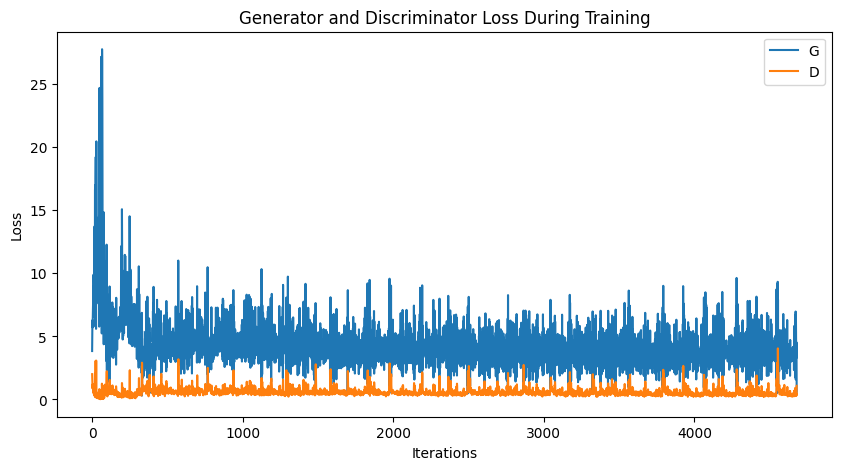

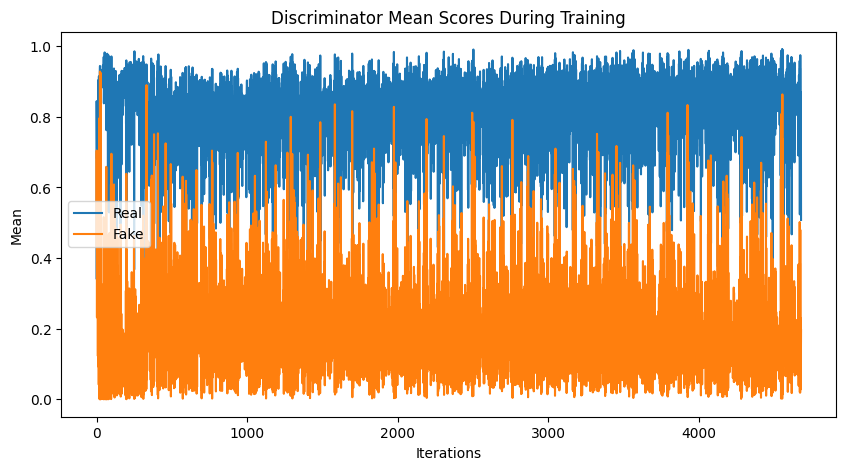

FID: 192.88412475585938
Running cfg1_nz120_ngf64_ndf64_lr0.0002_epochs20_beta10.5_seed42, seed=42
Starting Training Loop...
[0/20][0/234]	Loss_D: 1.9995	Loss_G: 3.9217	D(x): 0.3454	D(G(z)): 0.4479 / 0.0265
[0/20][50/234]	Loss_D: 0.0789	Loss_G: 11.4969	D(x): 0.9437	D(G(z)): 0.0000 / 0.0000
[0/20][100/234]	Loss_D: 1.3374	Loss_G: 13.3261	D(x): 0.5113	D(G(z)): 0.0003 / 0.0000
[0/20][150/234]	Loss_D: 1.0340	Loss_G: 5.1577	D(x): 0.9076	D(G(z)): 0.5717 / 0.0087
[0/20][200/234]	Loss_D: 0.4364	Loss_G: 5.0432	D(x): 0.9045	D(G(z)): 0.2428 / 0.0084
[1/20][0/234]	Loss_D: 0.3122	Loss_G: 6.4270	D(x): 0.8367	D(G(z)): 0.0959 / 0.0022
[1/20][50/234]	Loss_D: 0.1578	Loss_G: 5.1399	D(x): 0.9405	D(G(z)): 0.0831 / 0.0074
[1/20][100/234]	Loss_D: 0.3828	Loss_G: 5.1213	D(x): 0.7893	D(G(z)): 0.0496 / 0.0218
[1/20][150/234]	Loss_D: 0.5222	Loss_G: 2.8438	D(x): 0.8438	D(G(z)): 0.2333 / 0.1075
[1/20][200/234]	Loss_D: 0.5059	Loss_G: 4.1189	D(x): 0.8693	D(G(z)): 0.2648 / 0.0249
[2/20][0/234]	Loss_D: 1.3743	Loss_G: 6.9

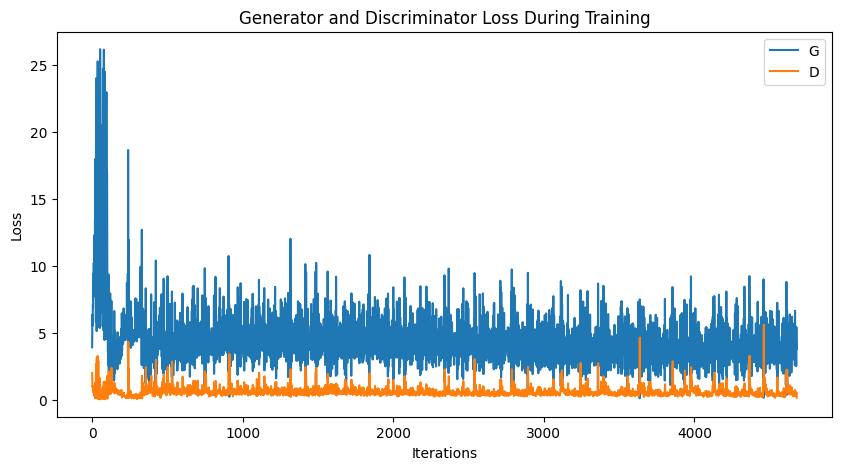

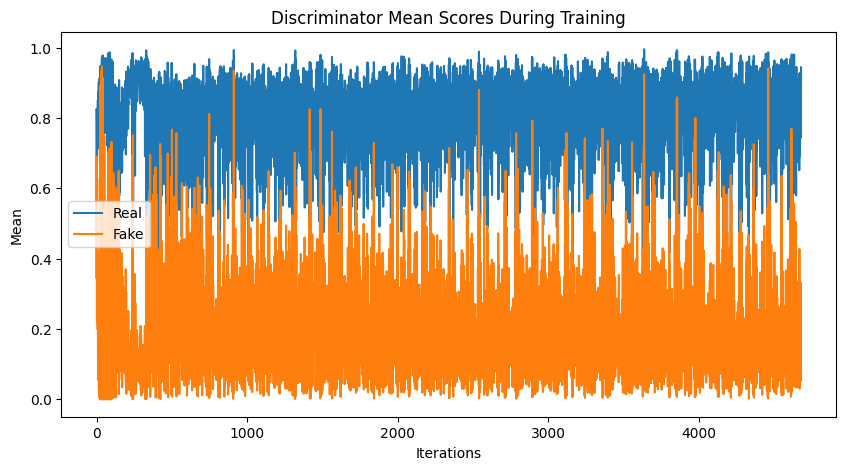

FID: 165.76602172851562
Running cfg2_nz64_ngf64_ndf64_lr0.0002_epochs20_beta10.5_seed42, seed=42
Starting Training Loop...
[0/20][0/234]	Loss_D: 2.1092	Loss_G: 1.2085	D(x): 0.2116	D(G(z)): 0.1879 / 0.3536
[0/20][50/234]	Loss_D: 0.2956	Loss_G: 17.9591	D(x): 0.8496	D(G(z)): 0.0000 / 0.0000
[0/20][100/234]	Loss_D: 0.6896	Loss_G: 5.3667	D(x): 0.8748	D(G(z)): 0.3708 / 0.0146
[0/20][150/234]	Loss_D: 0.4057	Loss_G: 5.6551	D(x): 0.8743	D(G(z)): 0.2054 / 0.0053
[0/20][200/234]	Loss_D: 0.2469	Loss_G: 6.3397	D(x): 0.9136	D(G(z)): 0.0908 / 0.0026
[1/20][0/234]	Loss_D: 0.8484	Loss_G: 2.8675	D(x): 0.6239	D(G(z)): 0.1630 / 0.0990
[1/20][50/234]	Loss_D: 0.6813	Loss_G: 3.4914	D(x): 0.8684	D(G(z)): 0.3560 / 0.0541
[1/20][100/234]	Loss_D: 0.3527	Loss_G: 3.4189	D(x): 0.8711	D(G(z)): 0.1587 / 0.0601
[1/20][150/234]	Loss_D: 0.5797	Loss_G: 3.0047	D(x): 0.7499	D(G(z)): 0.1832 / 0.0809
[1/20][200/234]	Loss_D: 0.2233	Loss_G: 3.7045	D(x): 0.9314	D(G(z)): 0.1259 / 0.0386
[2/20][0/234]	Loss_D: 0.5076	Loss_G: 4.066

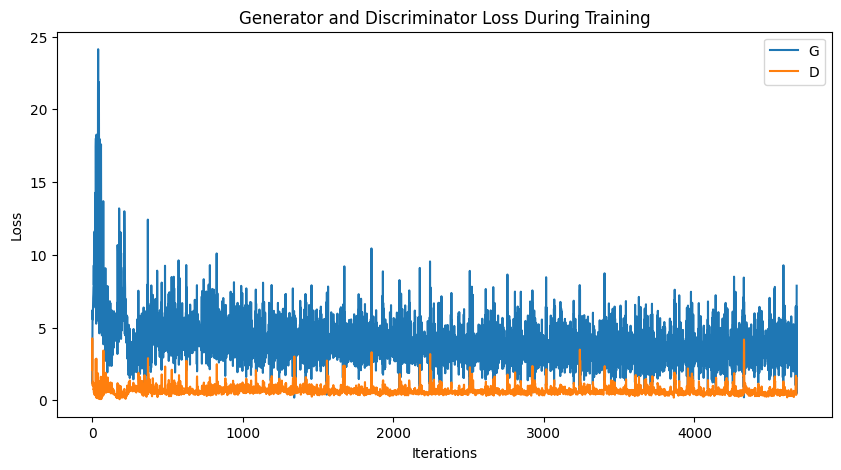

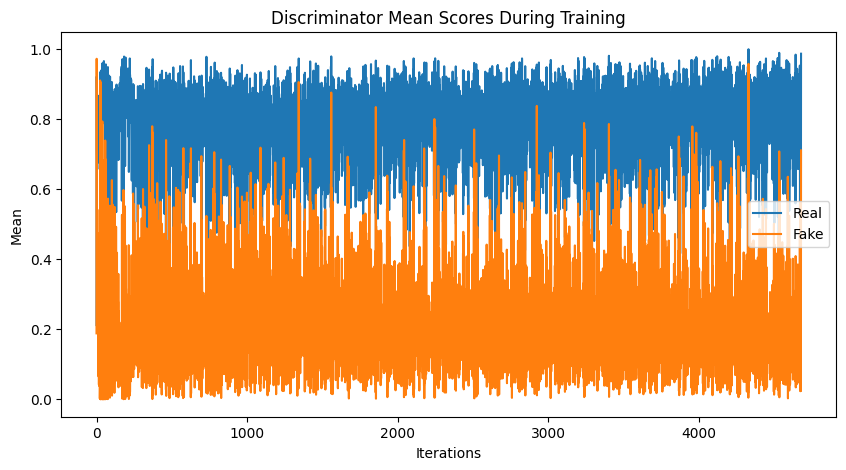

FID: 173.46559143066406
Running cfg3_nz100_ngf32_ndf64_lr0.0002_epochs20_beta10.5_seed42, seed=42
Starting Training Loop...
[0/20][0/234]	Loss_D: 1.5305	Loss_G: 7.4384	D(x): 0.7496	D(G(z)): 0.6231 / 0.0011
[0/20][50/234]	Loss_D: 0.0315	Loss_G: 31.6280	D(x): 0.9730	D(G(z)): 0.0000 / 0.0000
[0/20][100/234]	Loss_D: 0.1525	Loss_G: 6.0988	D(x): 0.9181	D(G(z)): 0.0427 / 0.0033
[0/20][150/234]	Loss_D: 0.3001	Loss_G: 4.3264	D(x): 0.8309	D(G(z)): 0.0169 / 0.0302
[0/20][200/234]	Loss_D: 0.1017	Loss_G: 7.1279	D(x): 0.9785	D(G(z)): 0.0744 / 0.0011
[1/20][0/234]	Loss_D: 2.3341	Loss_G: 15.4134	D(x): 0.9875	D(G(z)): 0.7911 / 0.0000
[1/20][50/234]	Loss_D: 0.3363	Loss_G: 3.6811	D(x): 0.8344	D(G(z)): 0.0515 / 0.0410
[1/20][100/234]	Loss_D: 0.1393	Loss_G: 7.0512	D(x): 0.9160	D(G(z)): 0.0096 / 0.0081
[1/20][150/234]	Loss_D: 0.3265	Loss_G: 3.2510	D(x): 0.9145	D(G(z)): 0.1559 / 0.0906
[1/20][200/234]	Loss_D: 0.1481	Loss_G: 6.8035	D(x): 0.9589	D(G(z)): 0.0717 / 0.0033
[2/20][0/234]	Loss_D: 0.3047	Loss_G: 4.0

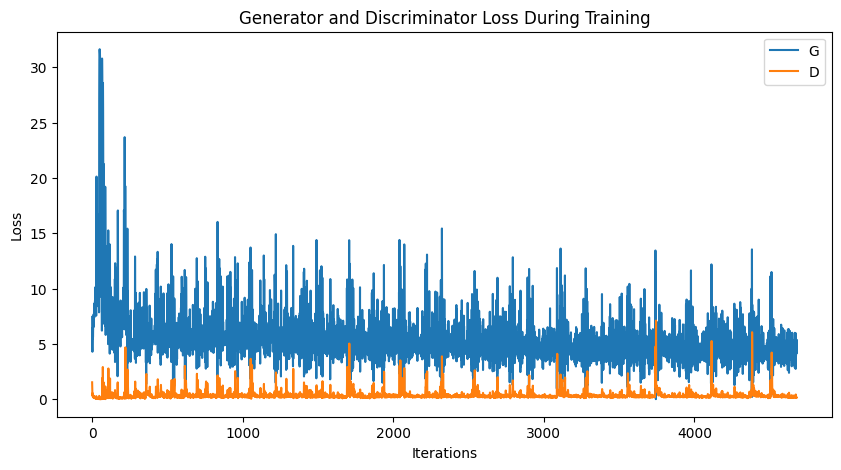

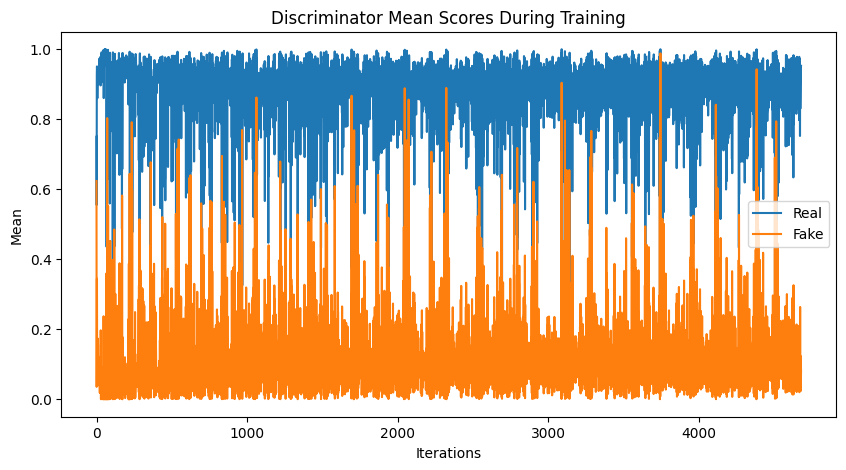

FID: 169.84288024902344
Running cfg4_nz100_ngf128_ndf64_lr0.0002_epochs20_beta10.5_seed42, seed=42
Starting Training Loop...
[0/20][0/234]	Loss_D: 1.8259	Loss_G: 6.5000	D(x): 0.6895	D(G(z)): 0.6838 / 0.0026
[0/20][50/234]	Loss_D: 0.3189	Loss_G: 5.9988	D(x): 0.8311	D(G(z)): 0.0064 / 0.0040
[0/20][100/234]	Loss_D: 1.0314	Loss_G: 3.4008	D(x): 0.7234	D(G(z)): 0.4471 / 0.0418
[0/20][150/234]	Loss_D: 1.0575	Loss_G: 2.4936	D(x): 0.6442	D(G(z)): 0.3366 / 0.1294
[0/20][200/234]	Loss_D: 0.7511	Loss_G: 4.5952	D(x): 0.7975	D(G(z)): 0.3403 / 0.0151
[1/20][0/234]	Loss_D: 1.1846	Loss_G: 7.1051	D(x): 0.8821	D(G(z)): 0.6205 / 0.0017
[1/20][50/234]	Loss_D: 1.7020	Loss_G: 1.3340	D(x): 0.2989	D(G(z)): 0.0530 / 0.3137
[1/20][100/234]	Loss_D: 1.1355	Loss_G: 2.5398	D(x): 0.7317	D(G(z)): 0.4845 / 0.1266
[1/20][150/234]	Loss_D: 0.9355	Loss_G: 2.1716	D(x): 0.6402	D(G(z)): 0.3048 / 0.1547
[1/20][200/234]	Loss_D: 0.6184	Loss_G: 3.4378	D(x): 0.7102	D(G(z)): 0.1935 / 0.0481
[2/20][0/234]	Loss_D: 0.8784	Loss_G: 5.21

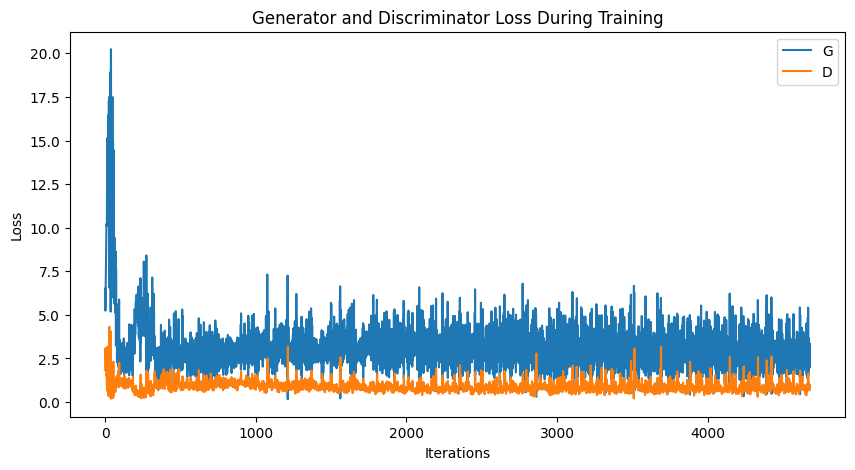

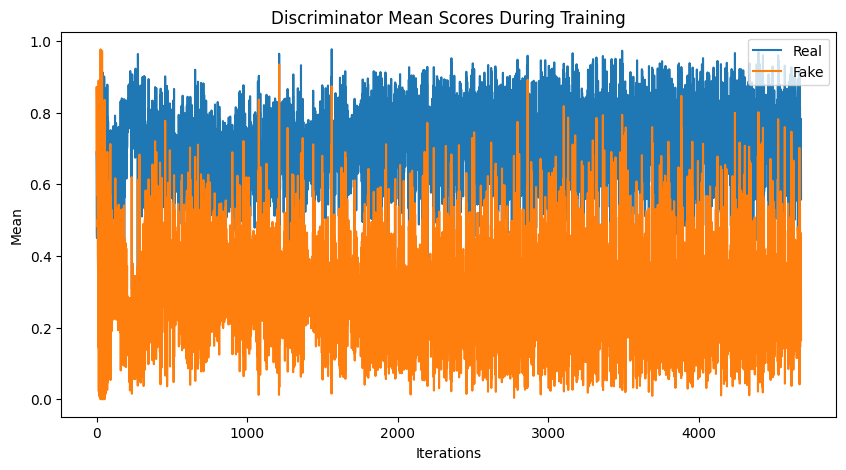

FID: 173.93455505371094
Running cfg5_nz100_ngf64_ndf32_lr0.0002_epochs20_beta10.5_seed42, seed=42
Starting Training Loop...
[0/20][0/234]	Loss_D: 1.4214	Loss_G: 2.3723	D(x): 0.5233	D(G(z)): 0.4809 / 0.1122
[0/20][50/234]	Loss_D: 0.3747	Loss_G: 5.5699	D(x): 0.8319	D(G(z)): 0.1300 / 0.0045
[0/20][100/234]	Loss_D: 0.5768	Loss_G: 3.3414	D(x): 0.7750	D(G(z)): 0.2232 / 0.0453
[0/20][150/234]	Loss_D: 0.5465	Loss_G: 2.4267	D(x): 0.7603	D(G(z)): 0.1951 / 0.1013
[0/20][200/234]	Loss_D: 0.4195	Loss_G: 4.9910	D(x): 0.8599	D(G(z)): 0.1916 / 0.0095
[1/20][0/234]	Loss_D: 0.6217	Loss_G: 5.7416	D(x): 0.8350	D(G(z)): 0.2911 / 0.0040
[1/20][50/234]	Loss_D: 0.3262	Loss_G: 4.2774	D(x): 0.7892	D(G(z)): 0.0405 / 0.0194
[1/20][100/234]	Loss_D: 0.7573	Loss_G: 3.2834	D(x): 0.7740	D(G(z)): 0.3303 / 0.0561
[1/20][150/234]	Loss_D: 0.6375	Loss_G: 3.5059	D(x): 0.7899	D(G(z)): 0.2844 / 0.0402
[1/20][200/234]	Loss_D: 0.7491	Loss_G: 2.4916	D(x): 0.7138	D(G(z)): 0.2757 / 0.0986
[2/20][0/234]	Loss_D: 0.9707	Loss_G: 2.675

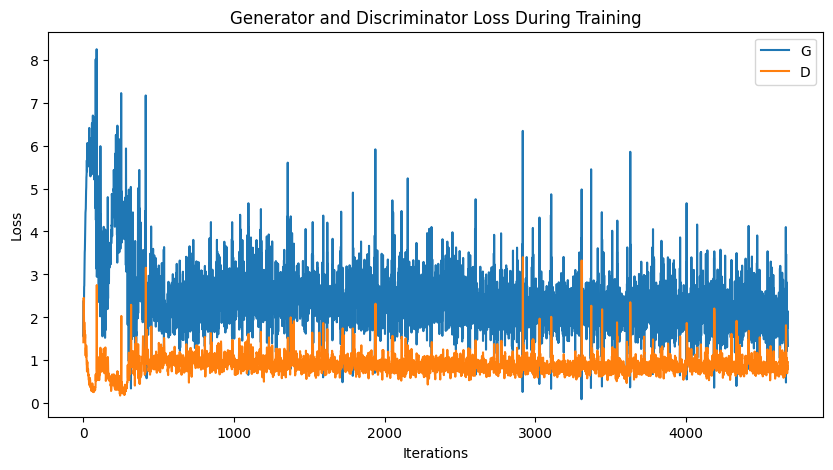

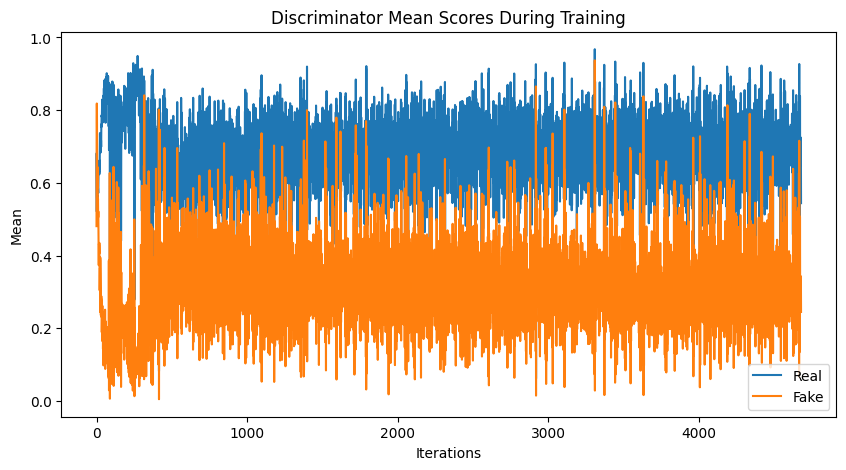

FID: 197.35923767089844
Running cfg6_nz100_ngf64_ndf128_lr0.0002_epochs20_beta10.5_seed42, seed=42
Starting Training Loop...
[0/20][0/234]	Loss_D: 2.5188	Loss_G: 17.3778	D(x): 0.5519	D(G(z)): 0.7358 / 0.0000
[0/20][50/234]	Loss_D: 0.0003	Loss_G: 60.9440	D(x): 0.9997	D(G(z)): 0.0000 / 0.0000
[0/20][100/234]	Loss_D: 0.0000	Loss_G: 60.4331	D(x): 1.0000	D(G(z)): 0.0000 / 0.0000
[0/20][150/234]	Loss_D: 0.0000	Loss_G: 60.0351	D(x): 1.0000	D(G(z)): 0.0000 / 0.0000
[0/20][200/234]	Loss_D: 0.0000	Loss_G: 60.0573	D(x): 1.0000	D(G(z)): 0.0000 / 0.0000
[1/20][0/234]	Loss_D: 0.0000	Loss_G: 59.8290	D(x): 1.0000	D(G(z)): 0.0000 / 0.0000
[1/20][50/234]	Loss_D: 0.0001	Loss_G: 59.8258	D(x): 0.9999	D(G(z)): 0.0000 / 0.0000
[1/20][100/234]	Loss_D: 0.0000	Loss_G: 59.8464	D(x): 1.0000	D(G(z)): 0.0000 / 0.0000
[1/20][150/234]	Loss_D: 0.0000	Loss_G: 59.5945	D(x): 1.0000	D(G(z)): 0.0000 / 0.0000
[1/20][200/234]	Loss_D: 0.0000	Loss_G: 59.6791	D(x): 1.0000	D(G(z)): 0.0000 / 0.0000
[2/20][0/234]	Loss_D: 0.0000	Lo

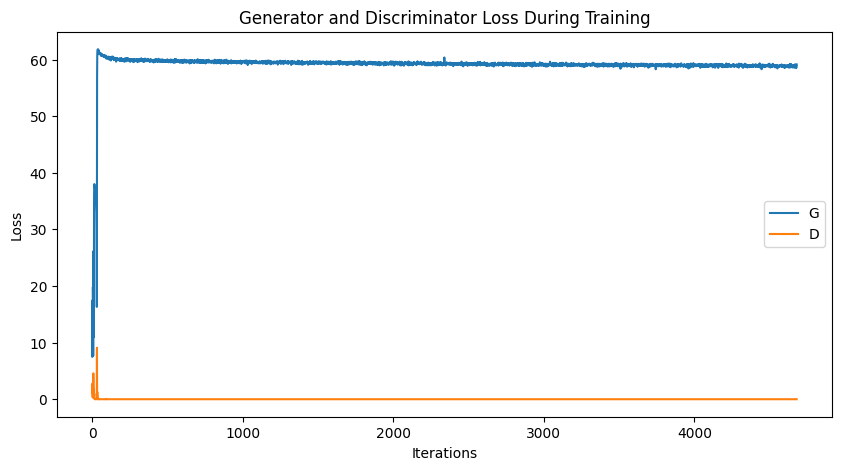

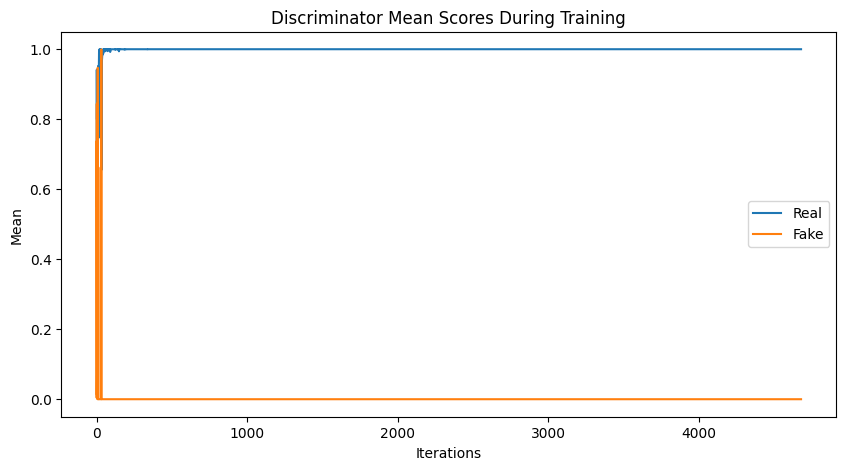

FID: 337.0654296875
Running cfg7_nz100_ngf64_ndf64_lr0.0001_epochs20_beta10.5_seed42, seed=42
Starting Training Loop...
[0/20][0/234]	Loss_D: 2.0093	Loss_G: 2.2323	D(x): 0.3427	D(G(z)): 0.4363 / 0.1407
[0/20][50/234]	Loss_D: 0.1069	Loss_G: 7.4487	D(x): 0.9648	D(G(z)): 0.0629 / 0.0008
[0/20][100/234]	Loss_D: 0.0414	Loss_G: 8.4996	D(x): 0.9848	D(G(z)): 0.0244 / 0.0002
[0/20][150/234]	Loss_D: 0.0223	Loss_G: 8.0685	D(x): 0.9912	D(G(z)): 0.0132 / 0.0004
[0/20][200/234]	Loss_D: 0.0151	Loss_G: 8.0220	D(x): 0.9922	D(G(z)): 0.0068 / 0.0004
[1/20][0/234]	Loss_D: 0.0123	Loss_G: 7.9826	D(x): 0.9940	D(G(z)): 0.0061 / 0.0004
[1/20][50/234]	Loss_D: 0.0055	Loss_G: 13.0216	D(x): 0.9946	D(G(z)): 0.0000 / 0.0000
[1/20][100/234]	Loss_D: 0.0278	Loss_G: 6.3333	D(x): 0.9845	D(G(z)): 0.0054 / 0.0019
[1/20][150/234]	Loss_D: 0.0070	Loss_G: 7.5236	D(x): 0.9980	D(G(z)): 0.0050 / 0.0006
[1/20][200/234]	Loss_D: 0.0575	Loss_G: 12.3987	D(x): 0.9644	D(G(z)): 0.0002 / 0.0000
[2/20][0/234]	Loss_D: 0.0310	Loss_G: 8.0217	

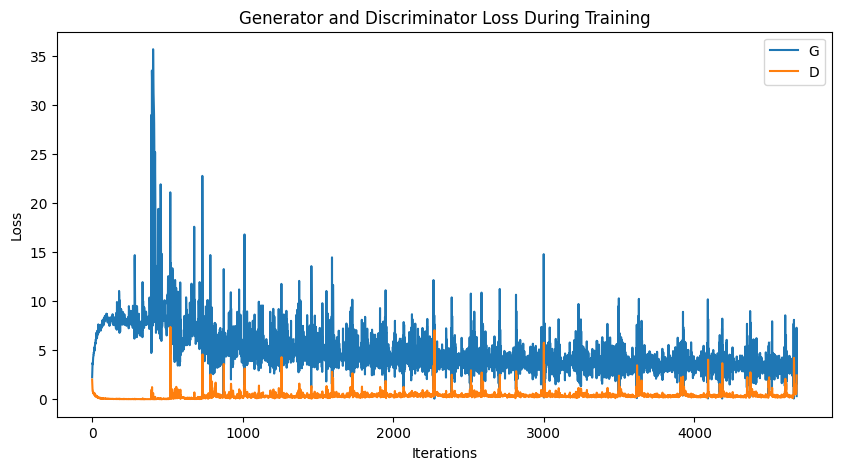

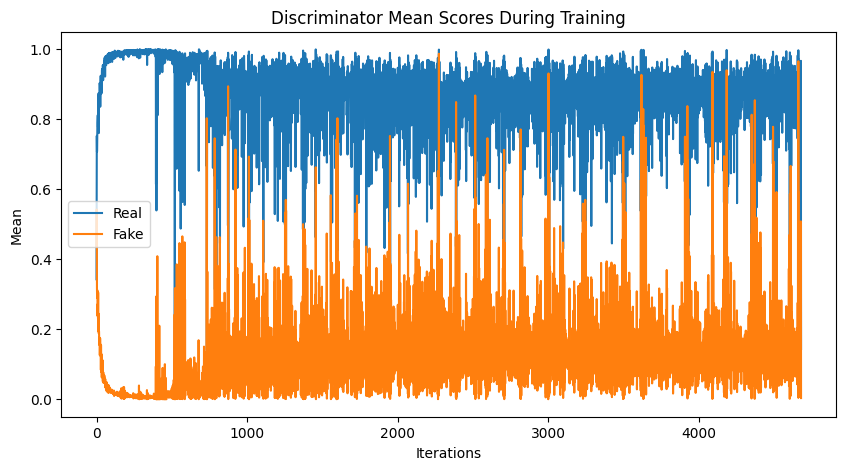

FID: 230.22482299804688
Running cfg8_nz100_ngf64_ndf64_lr0.0003_epochs20_beta10.5_seed42, seed=42
Starting Training Loop...
[0/20][0/234]	Loss_D: 2.0093	Loss_G: 5.5153	D(x): 0.3427	D(G(z)): 0.4363 / 0.0059
[0/20][50/234]	Loss_D: 0.4945	Loss_G: 7.1409	D(x): 0.7105	D(G(z)): 0.0303 / 0.0022
[0/20][100/234]	Loss_D: 0.9247	Loss_G: 2.5813	D(x): 0.6161	D(G(z)): 0.1586 / 0.0982
[0/20][150/234]	Loss_D: 0.3591	Loss_G: 4.7904	D(x): 0.8795	D(G(z)): 0.1625 / 0.0140
[0/20][200/234]	Loss_D: 0.4937	Loss_G: 4.6785	D(x): 0.7473	D(G(z)): 0.1139 / 0.0119
[1/20][0/234]	Loss_D: 0.7263	Loss_G: 5.9867	D(x): 0.9033	D(G(z)): 0.4151 / 0.0051
[1/20][50/234]	Loss_D: 0.5204	Loss_G: 3.5130	D(x): 0.8191	D(G(z)): 0.2137 / 0.0463
[1/20][100/234]	Loss_D: 0.6657	Loss_G: 2.8750	D(x): 0.6973	D(G(z)): 0.1802 / 0.0867
[1/20][150/234]	Loss_D: 0.7741	Loss_G: 3.4728	D(x): 0.7135	D(G(z)): 0.2413 / 0.0444
[1/20][200/234]	Loss_D: 1.2742	Loss_G: 5.4182	D(x): 0.8673	D(G(z)): 0.6198 / 0.0090
[2/20][0/234]	Loss_D: 1.0163	Loss_G: 0.341

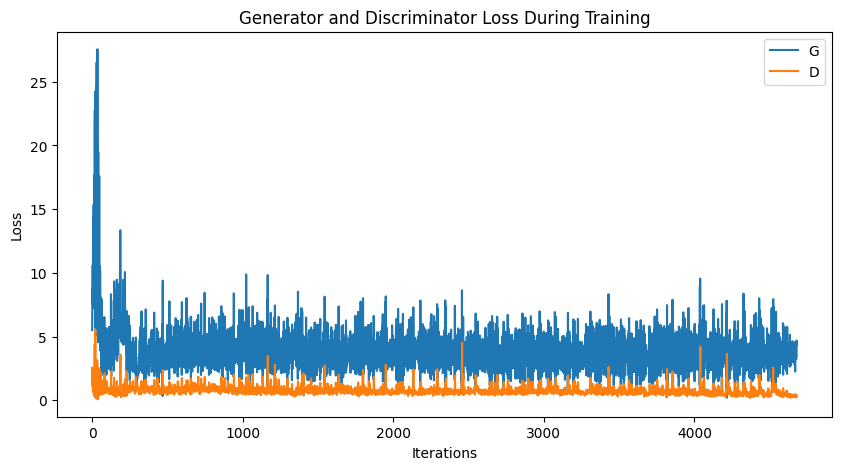

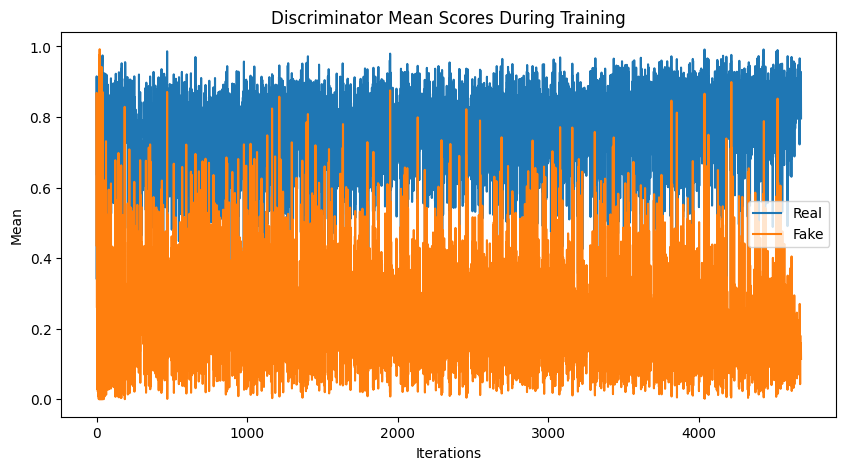

FID: 161.87318420410156
Running cfg9_nz100_ngf64_ndf64_lr0.0002_epochs10_beta10.5_seed42, seed=42
Starting Training Loop...
[0/10][0/234]	Loss_D: 2.0093	Loss_G: 3.8398	D(x): 0.3427	D(G(z)): 0.4363 / 0.0303
[0/10][50/234]	Loss_D: 0.2345	Loss_G: 7.0302	D(x): 0.9240	D(G(z)): 0.0604 / 0.0012
[0/10][100/234]	Loss_D: 0.5151	Loss_G: 4.6823	D(x): 0.7180	D(G(z)): 0.0307 / 0.0165
[0/10][150/234]	Loss_D: 0.7685	Loss_G: 3.7501	D(x): 0.8141	D(G(z)): 0.3264 / 0.0773
[0/10][200/234]	Loss_D: 0.4494	Loss_G: 6.7208	D(x): 0.9686	D(G(z)): 0.2669 / 0.0020
[1/10][0/234]	Loss_D: 0.3999	Loss_G: 5.6747	D(x): 0.8403	D(G(z)): 0.0968 / 0.0080
[1/10][50/234]	Loss_D: 0.4834	Loss_G: 3.3051	D(x): 0.7752	D(G(z)): 0.1389 / 0.0566
[1/10][100/234]	Loss_D: 0.6448	Loss_G: 3.1413	D(x): 0.6981	D(G(z)): 0.1222 / 0.0571
[1/10][150/234]	Loss_D: 0.7265	Loss_G: 3.3431	D(x): 0.7256	D(G(z)): 0.2414 / 0.0510
[1/10][200/234]	Loss_D: 0.6995	Loss_G: 5.2128	D(x): 0.8309	D(G(z)): 0.3380 / 0.0094
[2/10][0/234]	Loss_D: 0.4939	Loss_G: 5.699

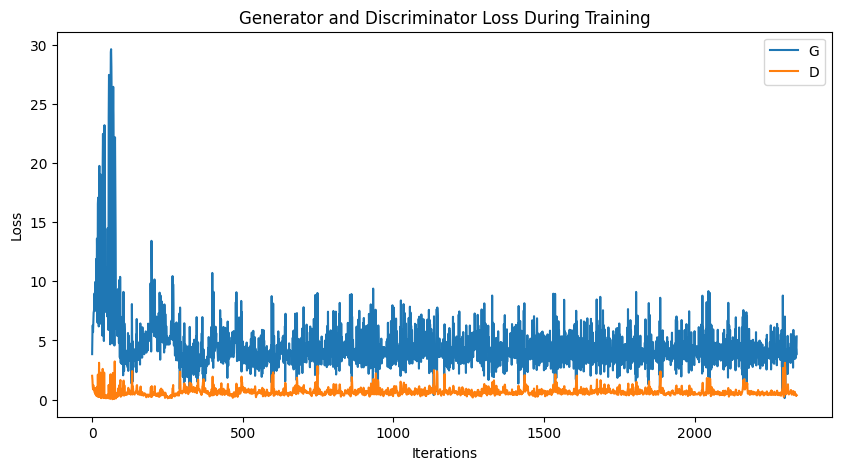

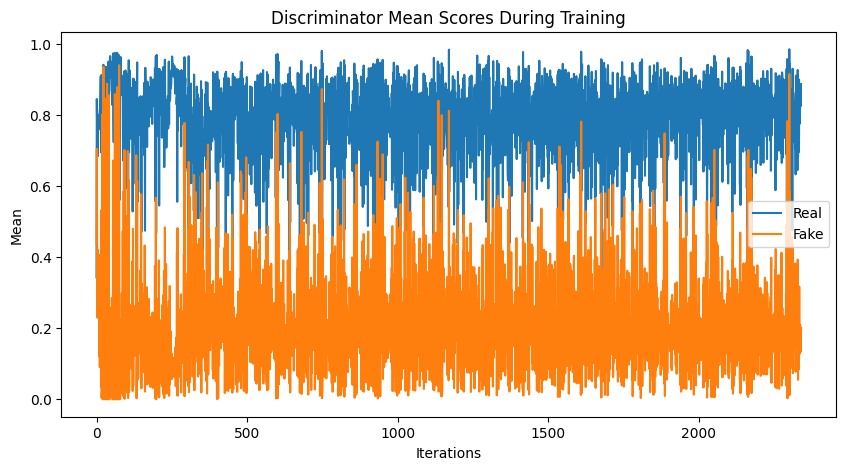

FID: 233.28662109375
Running cfg10_nz100_ngf64_ndf64_lr0.0002_epochs40_beta10.5_seed42, seed=42
Starting Training Loop...
[0/40][0/234]	Loss_D: 2.0093	Loss_G: 3.8402	D(x): 0.3427	D(G(z)): 0.4363 / 0.0303
[0/40][50/234]	Loss_D: 0.1174	Loss_G: 5.5578	D(x): 0.9674	D(G(z)): 0.0719 / 0.0055
[0/40][100/234]	Loss_D: 0.7901	Loss_G: 6.1394	D(x): 0.9079	D(G(z)): 0.4416 / 0.0041
[0/40][150/234]	Loss_D: 0.3837	Loss_G: 4.8748	D(x): 0.8403	D(G(z)): 0.1370 / 0.0118
[0/40][200/234]	Loss_D: 0.4154	Loss_G: 6.7367	D(x): 0.8380	D(G(z)): 0.1355 / 0.0017
[1/40][0/234]	Loss_D: 0.5877	Loss_G: 11.5788	D(x): 0.7257	D(G(z)): 0.0006 / 0.0000
[1/40][50/234]	Loss_D: 0.5193	Loss_G: 4.6915	D(x): 0.8717	D(G(z)): 0.2628 / 0.0134
[1/40][100/234]	Loss_D: 0.8017	Loss_G: 3.6378	D(x): 0.5833	D(G(z)): 0.0847 / 0.0437
[1/40][150/234]	Loss_D: 0.7549	Loss_G: 2.8038	D(x): 0.6187	D(G(z)): 0.0676 / 0.0827
[1/40][200/234]	Loss_D: 0.8075	Loss_G: 4.8882	D(x): 0.7025	D(G(z)): 0.2500 / 0.0187
[2/40][0/234]	Loss_D: 0.7319	Loss_G: 2.1854

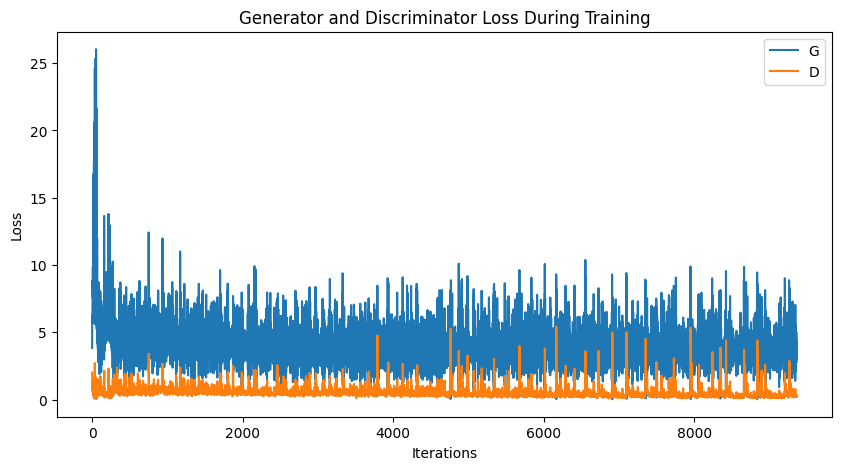

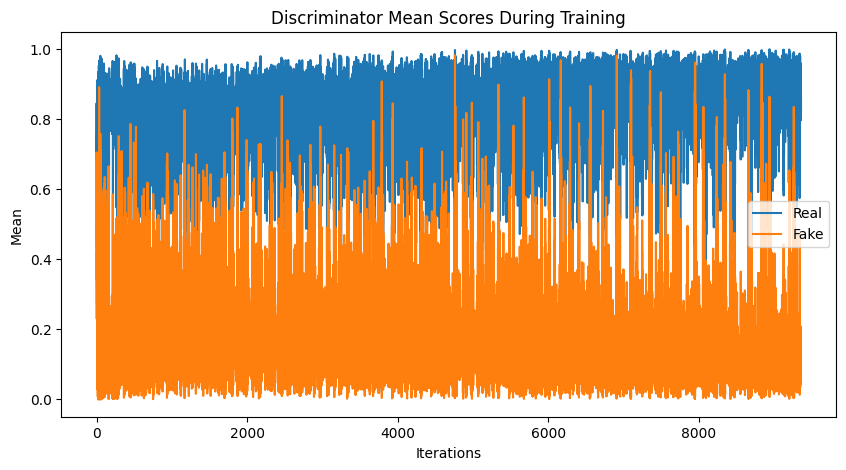

FID: 152.29075622558594
Running cfg11_nz100_ngf64_ndf64_lr0.0002_epochs20_beta10.6_seed42, seed=42
Starting Training Loop...
[0/20][0/234]	Loss_D: 2.0093	Loss_G: 3.8401	D(x): 0.3427	D(G(z)): 0.4363 / 0.0303
[0/20][50/234]	Loss_D: 0.1239	Loss_G: 20.5206	D(x): 0.9072	D(G(z)): 0.0000 / 0.0000
[0/20][100/234]	Loss_D: 0.0955	Loss_G: 7.9254	D(x): 0.9727	D(G(z)): 0.0588 / 0.0007
[0/20][150/234]	Loss_D: 0.8144	Loss_G: 3.5836	D(x): 0.6133	D(G(z)): 0.0380 / 0.0366
[0/20][200/234]	Loss_D: 0.1475	Loss_G: 6.5708	D(x): 0.9444	D(G(z)): 0.0767 / 0.0024
[1/20][0/234]	Loss_D: 0.1919	Loss_G: 13.5554	D(x): 0.8741	D(G(z)): 0.0005 / 0.0000
[1/20][50/234]	Loss_D: 0.1928	Loss_G: 6.2637	D(x): 0.9602	D(G(z)): 0.1135 / 0.0026
[1/20][100/234]	Loss_D: 0.2257	Loss_G: 5.7228	D(x): 0.9029	D(G(z)): 0.0419 / 0.0075
[1/20][150/234]	Loss_D: 1.2862	Loss_G: 3.6000	D(x): 0.4381	D(G(z)): 0.0033 / 0.0614
[1/20][200/234]	Loss_D: 0.2043	Loss_G: 4.0815	D(x): 0.8958	D(G(z)): 0.0544 / 0.0236
[2/20][0/234]	Loss_D: 0.4602	Loss_G: 5.

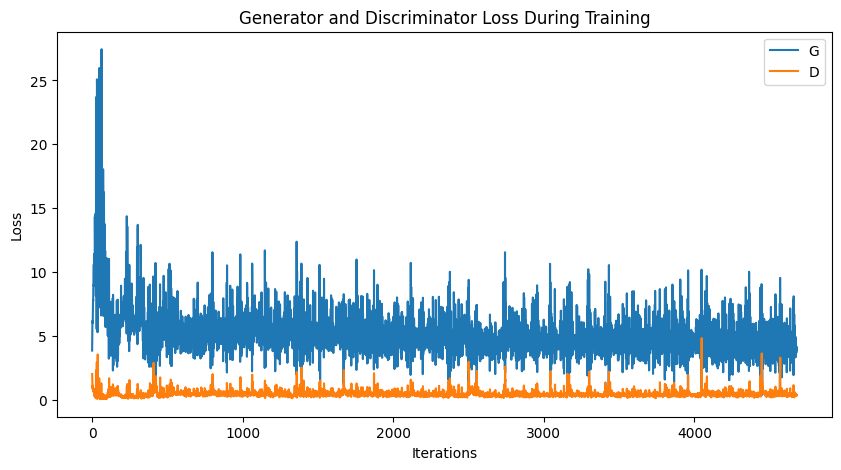

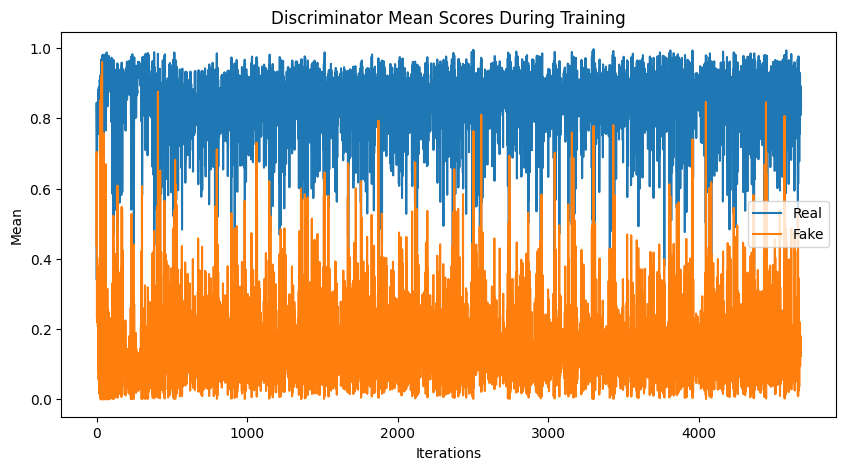

FID: 187.68182373046875
Running cfg12_nz100_ngf64_ndf64_lr0.0002_epochs20_beta10.4_seed42, seed=42
Starting Training Loop...
[0/20][0/234]	Loss_D: 2.0093	Loss_G: 3.8401	D(x): 0.3427	D(G(z)): 0.4363 / 0.0303
[0/20][50/234]	Loss_D: 0.0976	Loss_G: 7.7525	D(x): 0.9687	D(G(z)): 0.0580 / 0.0005
[0/20][100/234]	Loss_D: 1.8127	Loss_G: 3.1277	D(x): 0.3887	D(G(z)): 0.0306 / 0.0591
[0/20][150/234]	Loss_D: 0.4103	Loss_G: 7.0240	D(x): 0.9237	D(G(z)): 0.2605 / 0.0013
[0/20][200/234]	Loss_D: 1.1825	Loss_G: 12.2517	D(x): 0.8370	D(G(z)): 0.4800 / 0.0002
[1/20][0/234]	Loss_D: 0.1385	Loss_G: 5.4184	D(x): 0.9193	D(G(z)): 0.0340 / 0.0072
[1/20][50/234]	Loss_D: 0.5308	Loss_G: 5.3802	D(x): 0.8981	D(G(z)): 0.2719 / 0.0089
[1/20][100/234]	Loss_D: 1.7855	Loss_G: 4.7817	D(x): 0.8548	D(G(z)): 0.6771 / 0.0158
[1/20][150/234]	Loss_D: 0.5617	Loss_G: 3.4712	D(x): 0.8060	D(G(z)): 0.2267 / 0.0467
[1/20][200/234]	Loss_D: 0.6704	Loss_G: 4.0177	D(x): 0.7634	D(G(z)): 0.2451 / 0.0264
[2/20][0/234]	Loss_D: 1.0703	Loss_G: 2.9

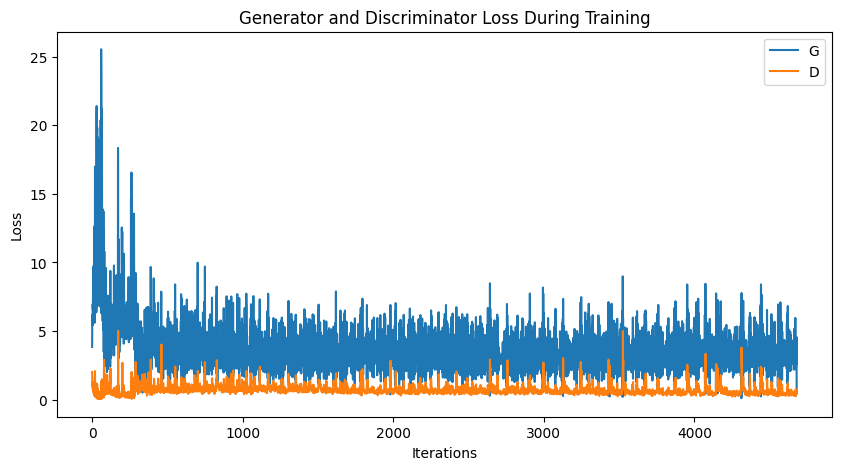

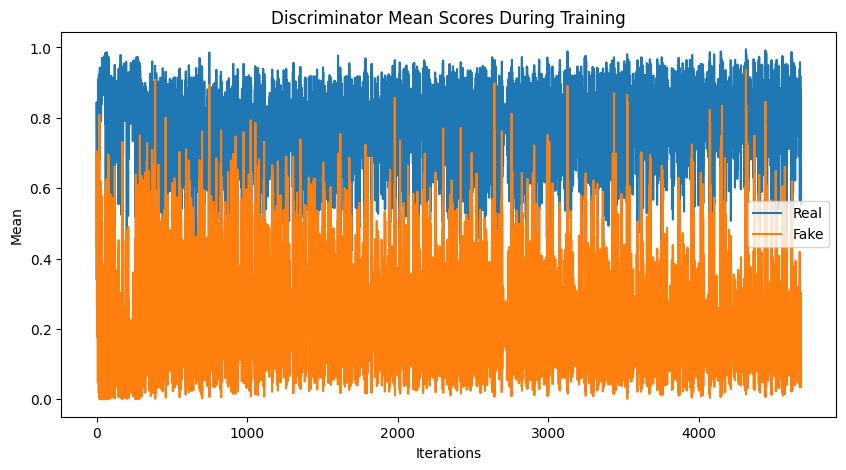

FID: 162.83090209960938
Results saved to: experiments/dcgan/fid_results.xlsx


In [ ]:
# ========== Fixed Params ==========
main_dir = os.path.join('experiments', 'dcgan')
if not os.path.exists(main_dir):
    os.mkdir(main_dir)
dataroot = os.path.join(os.path.join('data', 'cats'), 'Data')
workers = 2
batch_size = 128
image_size = 64
nc = 3 # Number of channels in the training images
ngpu = 1 if torch.cuda.is_available() else 0
device = torch.device("cuda:0" if ngpu > 0 else "cpu")
seed = 42


# ========== Configurations ==========

# nz - Size of z latent vector (i.e. size of generator input)
# ngf - Size of feature maps in generator
# ndf - Size of feature maps in discriminator
# num_epochs - Number of training epochs
# lr - Learning rate for optimizers
# beta1 - Beta1 hyperparameter for Adam optimizers

configs = [
    {'nz': 100, 'ngf': 64, 'ndf': 64, 'lr': 0.0002, 'num_epochs': 120, 'beta1': 0.5},

    {'nz': 120, 'ngf': 64, 'ndf': 64, 'lr': 0.0002, 'num_epochs': 120, 'beta1': 0.5},
    {'nz': 64, 'ngf': 64, 'ndf': 64, 'lr': 0.0002, 'num_epochs': 120, 'beta1': 0.5},

    {'nz': 100, 'ngf': 32, 'ndf': 64, 'lr': 0.0002, 'num_epochs': 120, 'beta1': 0.5},
    {'nz': 100, 'ngf': 128, 'ndf': 64, 'lr': 0.0002, 'num_epochs': 120, 'beta1': 0.5},

    {'nz': 100, 'ngf': 64, 'ndf': 32, 'lr': 0.0002, 'num_epochs': 120, 'beta1': 0.5},
    {'nz': 100, 'ngf': 64, 'ndf': 128, 'lr': 0.0002, 'num_epochs': 120, 'beta1': 0.5},

    {'nz': 100, 'ngf': 64, 'ndf': 64, 'lr': 0.0001, 'num_epochs': 120, 'beta1': 0.5},
    {'nz': 100, 'ngf': 64, 'ndf': 64, 'lr': 0.0003, 'num_epochs': 120, 'beta1': 0.5},

    {'nz': 100, 'ngf': 64, 'ndf': 64, 'lr': 0.0002, 'num_epochs': 150, 'beta1': 0.5},
    {'nz': 100, 'ngf': 64, 'ndf': 64, 'lr': 0.0002, 'num_epochs': 200, 'beta1': 0.5},

    {'nz': 100, 'ngf': 64, 'ndf': 64, 'lr': 0.0002, 'num_epochs': 120, 'beta1': 0.6},
    {'nz': 100, 'ngf': 64, 'ndf': 64, 'lr': 0.0002, 'num_epochs': 120, 'beta1': 0.4},
]

# ========== Prepare Dataset ==========
dataset = CatsDS(dataroot,
    transform=transforms.Compose([
        transforms.Resize(image_size),
        transforms.CenterCrop(image_size),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    ])
)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size,
                                         shuffle=True, num_workers=workers)

# ========== Run Experiments ==========
results = []

for cfg_idx, config in enumerate(configs):
    nz, ngf, ndf, lr, num_epochs, beta1 = config['nz'], config['ngf'], config['ndf'], config['lr'], config['num_epochs'], config['beta1']
    experiment_name = f"cfg{cfg_idx}_nz{nz}_ngf{ngf}_ndf{ndf}_lr{lr}_epochs{num_epochs}_beta1{beta1}_seed{seed}"
    experiment_dir = os.path.join(main_dir, experiment_name)
    if not os.path.exists(experiment_dir):
        os.mkdir(experiment_dir)
    #fids = []

    # for run_idx, seed in enumerate([0, 1, 2]):
    print(f"Running {experiment_name}, seed={seed}")
    torch.manual_seed(seed)
    random.seed(seed)

    # Initialize models
    netG = Generator(ngpu, nz=nz, ngf=ngf, nc=nc).to(device)
    netD = Discriminator(ngpu, ndf=ndf, nc=nc).to(device)
    if device.type == 'cuda' and ngpu > 1:
        netG = nn.DataParallel(netG, list(range(ngpu)))
        netD = nn.DataParallel(netD, list(range(ngpu)))
    netG.apply(weights_init)
    netD.apply(weights_init)

    # Optimizers and criterion
    criterion = nn.BCELoss()
    optimizerD = optim.Adam(netD.parameters(), lr=lr, betas=(beta1, 0.999))
    optimizerG = optim.Adam(netG.parameters(), lr=lr, betas=(beta1, 0.999))

    # Train
    run_dir = experiment_dir # if run_idx == 0 else None
    training(num_epochs, nz, dataloader, netD, netG, device, criterion, optimizerD, optimizerG, run_dir)

    # Evaluation + image generation only once
    if run_dir:
        display_results(run_dir)
        save_fake_imgs(ngpu, nz, ngf, nc, device, run_dir, random_state=seed)
        generate_interpol_dcgan(run_dir, ngpu, nz, ngf, nc, device)

    # # FID computation (assumes save_fake_imgs saves images in run_dir + "/fake_images")
    # fid = calculate_fid(real_path=dataroot, fake_path=os.path.join(run_dir, "fake_images"))
    # fids.append(fid)

    # mean_fid = sum(fids) / len(fids)
    # std_fid = (sum([(f - mean_fid) ** 2 for f in fids]) / len(fids)) ** 0.5
    # results.append({
    #     "config": experiment_name,
    #     "nz": nz, "ngf": ngf, "ndf": ndf, "lr": lr,
    #     "FID_mean": mean_fid, "FID_std": std_fid
    # })
    fid = calculate_fid(
        real_path=dataroot,
        fake_path=os.path.join(run_dir, 'fake_imgs'),
        device=device
    )
    results.append({
        "config": experiment_name,
        "nz": nz, "ngf": ngf, "ndf": ndf, "lr": lr, "epochs": num_epochs, "beta1": beta1,
        f"fid_{seed}": fid
    })
    print("FID:", fid)


# ========== Save Results ==========
df = pd.DataFrame(results)
df.to_excel(os.path.join(main_dir, "fid_results_more_epochs.xlsx"), index=False)
print("Results saved to:", os.path.join(main_dir, "fid_results_more_epochs.xlsx"))
